In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd
from scipy.io import arff
import statistics

In [2]:
# Utilities

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
    
        return cost.mean()

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        n = w_in.shape
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

In [3]:
train_data, meta = arff.loadarff('KDDTrain+.arff')
df = pd.DataFrame(train_data)
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
for col in ['protocol_type', 'service', 'flag', 'class']:
    df[col] = df[col].astype('category').cat.codes

In [4]:
# split training data into X and Y
# Isolating some categories that don't need encoding or cleaning
# n-feature isolated picture to demonstrate the difference in scaled and non-scaled features
# and gain experience plotting
train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)

print(train_X[:5])
print(train_y[:5])
print(train_X.shape, train_X.dtype)      # expect (~125973, 2) and float64
print(train_y.shape, train_y.dtype)

[[0.000e+00 1.000e+00 2.000e+01 9.000e+00 4.910e+02 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 2.000e+00 2.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e+00 0.000e+00 0.000e+00 1.500e+02 2.500e+01 1.700e-01 3.000e-02
  1.700e-01 0.000e+00 0.000e+00 0.000e+00 5.000e-02 0.000e+00]
 [0.000e+00 2.000e+00 4.400e+01 9.000e+00 1.460e+02 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 1.300e+01 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  8.000e-02 1.500e-01 0.000e+00 2.550e+02 1.000e+00 0.000e+00 6.000e-01
  8.800e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.000e+00 4.900e+01 5.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+0

In [10]:
# Fit n-feature training data to model!
# init weights and biases...
w_in = np.zeros_like(train_X[0])
b_in = 0
alpha = 0.1
iters = 10000
#scaled_train_X = (train_X - train_X.mean(axis=0)) / train_X.std(axis=0)
scaled_train_X = train_X
stdevs = train_X.std(axis=0)
stdevs = np.clip(stdevs, 1e-7, None)
scaled_train_X = (train_X - train_X.mean(axis=0)) / stdevs
scaled_train_X[4:6] = np.log1p(train_X[4:6])
print(scaled_train_X[0])
# print(np.ptp(scaled_train_X, axis=0))
# print(scaled_train_X[:5])
#plt.plot(np.zeros_like(scaled_train_X), scaled_train_X, 'x')
#plt.show()

[-0.11024922 -0.12470616 -0.68678521  0.75111129 -0.0076786  -0.00491864
 -0.01408881 -0.08948642 -0.00773599 -0.09507567 -0.02702282 -0.80926182
 -0.01166364 -0.03665187 -0.02443651 -0.01238515 -0.02618002 -0.0186099
 -0.0412212   0.         -0.00281749 -0.09753094 -0.71704549 -0.35434285
 -0.63720927 -0.63192903 -0.37436224 -0.3744316   0.77128311 -0.34968303
 -0.3745597  -0.32406309 -0.81888998 -0.78236683 -0.28028168  0.06997226
 -0.2891034  -0.63953191 -0.6248708  -0.22453241 -0.37638703]


In [11]:
#w,b,J_history = gradient_descent(train_X, train_y, w_in, b_in, alpha, iters)
#print(f"New weights: {w}, new bias: {b}")

# The above code does not work!
# Since there are unscaled pieces of data (which are in the thousands)
# Predictions being fed into sigmoid (X[i]@w + b)
# are so large. Coupled with exp() being... exponential, overflow is inevitable
# So, scaling is not just for better results, it is impossible not to scale!

In [12]:
w,b,J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters)
print(f"New weights: {w}, new bias: {b}")

Iteration    0: Cost 0.5757050567528348
Iteration 1000: Cost 0.12405654324678109
Iteration 2000: Cost 0.12053543205647929
Iteration 3000: Cost 0.11874337423767717
Iteration 4000: Cost 0.11764623232075257
Iteration 5000: Cost 0.11691725699397108
Iteration 6000: Cost 0.11639382001758576
Iteration 7000: Cost 0.11599836513118814
Iteration 8000: Cost 0.11569157739254751
Iteration 9000: Cost 0.11544606948285516
New weights: [ 0.06896416  0.71119669  0.00687603 -0.8221567  -0.17678108 -0.02876372
  0.07091855 -1.02714279 -0.01525912 -1.17265841 -0.02270445  0.2935358
 -0.12140013 -0.06372612  0.12606682  0.15389044  0.29388568 -0.01156907
  0.07363366  0.          0.01740323  1.13226363 -1.24065646  0.26062992
 -0.47166709 -1.04770447 -0.11678493 -1.03782133  1.25018067  0.36644522
 -0.24501207 -0.86170143  1.54790113 -1.01480952 -0.31663208 -0.8247278
 -0.30624371 -0.51761855 -0.95375627 -0.22889887 -0.18209426], new bias: -0.34350751318753564


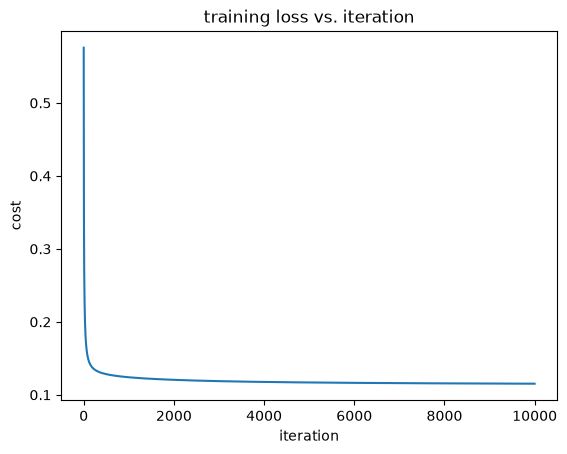

In [13]:
# plot cost vs. iterations
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("training loss vs. iteration")
plt.show()

In [14]:
preds = (sigmoid(train_X @ w + b) >= 0.5).astype(int)
print((preds == train_y).mean())

0.7432465687091678


In [15]:
# Displays proportion of dataset that is labeled normal and attack
print(train_y.mean())
print(1 - train_y.mean())

0.5345828074269883
0.46541719257301173


In [16]:
# Below is an education plot
# Assuming training on two features (any 2, but here src and dst bytes)
# Plots a scatter plot on src vs. dst bytes, points colour coded for attack or normal classification
# with decision boundary 
# x1 = scaled_train_X[:, 0]
# x2 = scaled_train_X[:, 1]

# plt.figure(figsize=(8, 6))

# y=train_y
# # scatter the two classes separately so they get different colours + a legend
# plt.scatter(x1[y == 0], x2[y == 0], s=5, alpha=0.3, label="normal")
# plt.scatter(x1[y == 1], x2[y == 1], s=5, alpha=0.3, label="attack")

# # the decision boundary: the line where w0*x1 + w1*x2 + b = 0
# # rearranged for x2:  x2 = -(w0*x1 + b) / w1
# xs = np.linspace(x1.min(), x1.max(), 200)
# boundary = -(w[0] * xs + b) / w[1]
# plt.plot(xs, boundary, color="black", linewidth=2, label="decision boundary")

# plt.xlabel("log src_bytes (scaled)")
# plt.ylabel("log dst_bytes (scaled)")
# plt.legend()
# plt.ylim(x2.min(), x2.max())   # keep the view on the data if the line shoots off
# plt.show()

In [17]:
# Get test inputs
test_data, test_meta = arff.loadarff('KDDTest+.arff')
test_df = pd.DataFrame(test_data)

for col in test_df.select_dtypes([object]):
        test_df[col] = test_df[col].str.decode('utf-8')
for col in ['protocol_type', 'service', 'flag', 'class']:
    test_df[col] = test_df[col].astype('category').cat.codes

test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

In [18]:
preds = (sigmoid(test_X @ w + b) >= 0.5).astype(int)
print((preds == test_y).mean())

0.7258694109297374
